In [2]:
import pandas as pd
import numpy as np

def preprocess_weather_data(file_path, output_path=None):
    """
    对气象数据进行预处理:
    1. 将英文列名转换为中文
    2. 将缺失值或空白数据填充为0
    
    Parameters:
    -----------
    file_path : str
        输入Excel文件路径
    output_path : str, optional
        输出Excel文件路径，若为None则使用默认命名
    
    Returns:
    --------
    df : pandas.DataFrame
        处理后的数据框
    """
    # 读取Excel文件
    try:
        df = pd.read_excel(file_path)
        print(f"成功读取文件: {file_path}")
        print(f"原始数据形状: {df.shape}")
    except Exception as e:
        print(f"读取文件时出错: {e}")
        return None
    
    # 列名英文到中文的映射字典
    column_mapping = {
        '当地时间': '当地时间',  # 保持不变
        'T': '气温(℃)',
        'Po': '站点气压(hPa)',
        'P': '气压(hPa)',
        'Pa': '海平面气压(hPa)',
        'U': '相对湿度(%)',
        'DD': '风向(°)',
        'Ff': '风速(m/s)',
        'ff10': '10分钟平均风速(m/s)',
        'ff3': '3小时平均风速(m/s)',
        'N': '总云量',
        'WW': '现在天气',
        'W1': '过去天气1',
        'W2': '过去天气2',
        'Tn': '最低温度(℃)',
        'Tx': '最高温度(℃)',
        'Cl': '低云类型',
        'Nh': '低云量',
        'H': '云底高度(m)',
        'Cm': '中云类型',
        'Ch': '高云类型',
        'VV': '水平能见度(m)',
        'Td': '露点温度(℃)',
        'RRR': '降水量(mm)',
        'tR': '降水持续时间(h)',
        'E': '蒸发量(mm)',
        'Tg': '地表温度(℃)',
        'E\'': '蒸发皿蒸发量(mm)',
        'sss': '土壤含水量'
    }
    
    # 检查输入数据的列是否都在映射字典中
    missing_columns = [col for col in df.columns if col not in column_mapping]
    if missing_columns:
        print(f"警告: 以下列在映射字典中不存在: {missing_columns}")
        # 为缺失的列添加默认映射（保持原名称）
        for col in missing_columns:
            column_mapping[col] = col
    
    # 重命名列
    df = df.rename(columns=column_mapping)
    
    # 填充缺失值和空白值为0
    df = df.replace([np.nan, '', ' '], 0)
    
    # 显示处理后的数据信息
    print(f"处理后的数据形状: {df.shape}")
    print("处理后的列名:")
    for col in df.columns:
        print(f"  - {col}")
    
    # 保存处理后的数据
    if output_path is None:
        output_path = file_path.replace('.xlsx', '_processed.xlsx')
        if output_path == file_path:  # 如果文件名没有.xlsx后缀
            output_path = file_path + '_processed.xlsx'
    
    try:
        df.to_excel(output_path, index=False)
        print(f"处理后的数据已保存到: {output_path}")
    except Exception as e:
        print(f"保存文件时出错: {e}")
    
    return df

# 使用示例
if __name__ == "__main__":
    # 替换为您的文件路径
    file_path = "西安所有.xlsx"
    preprocess_weather_data(file_path)

成功读取文件: 西安所有.xlsx
原始数据形状: (56206, 29)
警告: 以下列在映射字典中不存在: ['当地时间 西安']
处理后的数据形状: (56206, 29)
处理后的列名:
  - 当地时间 西安
  - 气温(℃)
  - 站点气压(hPa)
  - 气压(hPa)
  - 海平面气压(hPa)
  - 相对湿度(%)
  - 风向(°)
  - 风速(m/s)
  - 10分钟平均风速(m/s)
  - 3小时平均风速(m/s)
  - 总云量
  - 现在天气
  - 过去天气1
  - 过去天气2
  - 最低温度(℃)
  - 最高温度(℃)
  - 低云类型
  - 低云量
  - 云底高度(m)
  - 中云类型
  - 高云类型
  - 水平能见度(m)
  - 露点温度(℃)
  - 降水量(mm)
  - 降水持续时间(h)
  - 蒸发量(mm)
  - 地表温度(℃)
  - 蒸发皿蒸发量(mm)
  - 土壤含水量
处理后的数据已保存到: 西安所有_processed.xlsx


In [2]:
# !!pip install tensorflow

发现降水量异常值个数: 760


C:\Users\Zhong\AppData\Local\Temp\ipykernel_66940\167937264.py:83: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[feature].fillna(df[feature].mean(), inplace=True)
C:\Users\Zhong\AppData\Local\Temp\ipykernel_66940\167937264.py:92: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

'雨纷纷'天气占比: 8.53%


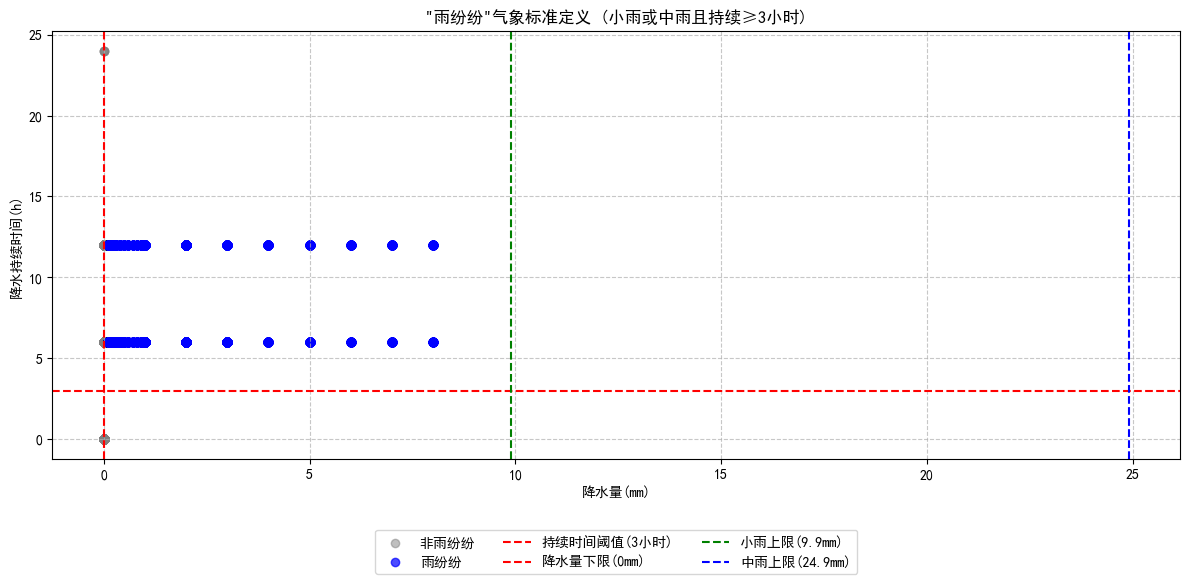

训练集形状: (44959, 7, 8), 测试集形状: (11240, 7, 8)
训练集中'雨纷纷'标签分布: [41487  3472]
训练集中'雨纷纷'占比: 7.72%


C:\Users\Zhong\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


应用SMOTE后训练集形状: (82974, 7, 8)
应用SMOTE后训练集中'雨纷纷'标签分布: [41487 41487]
应用SMOTE后训练集中'雨纷纷'占比: 50.00%
Epoch 1/50


C:\Users\Zhong\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2075/2075 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.7702 - loss: 0.4758 - val_accuracy: 0.7795 - val_loss: 0.5544
Epoch 2/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8190 - loss: 0.3926 - val_accuracy: 0.8549 - val_loss: 0.4412
Epoch 3/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.8380 - loss: 0.3629 - val_accuracy: 0.8036 - val_loss: 0.5328
Epoch 4/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.8493 - loss: 0.3424 - val_accuracy: 0.8547 - val_loss: 0.4227
Epoch 5/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8543 - loss: 0.3284 - val_accuracy: 0.8739 - val_loss: 0.3730
Epoch 6/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8621 - loss: 0.3125 - val_accuracy: 0.8815 - val_loss: 0.3590
Epoch 7/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8723 - loss: 0.2962 - val_accuracy: 0.8924 - val_loss: 0.3577
Epoch 8/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8795 - loss: 0.28

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, f1_score, precision_score, recall_score, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout
import seaborn as sns
from imblearn.over_sampling import SMOTE  # 导入SMOTE过采样

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# 读取数据
df = pd.read_excel("西安2.xlsx")

# 将"降水量(mm)"列的"无降水"编码为0
if '降水量(mm)' in df.columns:
    df['降水量(mm)'] = df['降水量(mm)'].replace('无降水', 0)
    df['降水量(mm)'] = pd.to_numeric(df['降水量(mm)'], errors='coerce')

# 将时间列转换为datetime格式
time_column = None
for col in df.columns:
    if '时间' in col:
        time_column = col
        break

if time_column:
    df[time_column] = pd.to_datetime(df[time_column], format='%d.%m.%Y %H:%M')
    # 按时间排序
    df = df.sort_values(by=time_column)

# 处理异常值
def detect_outliers(df, column, threshold=3):
    """使用Z-score方法检测异常值"""
    z_scores = np.abs((df[column] - df[column].mean()) / df[column].std())
    return df[z_scores > threshold].index

# 处理降水量异常值
outlier_indices = detect_outliers(df, '降水量(mm)')
print(f"发现降水量异常值个数: {len(outlier_indices)}")

# 使用三次样条插值处理异常值
if len(outlier_indices) > 0:
    # 保存原始异常值用于比较
    original_values = df.loc[outlier_indices, '降水量(mm)'].copy()
    
    # 创建不包含异常值的临时数据框
    temp_df = df.drop(outlier_indices)
    
    # 使用三次样条插值填充异常值
    from scipy.interpolate import interp1d
    if len(temp_df) > 3:  # 确保有足够的数据点进行插值
        x = np.array((temp_df.index.astype(float)))
        y = temp_df['降水量(mm)'].values
        
        # 使用三次样条插值
        f = interp1d(x, y, kind='cubic', fill_value='extrapolate')
        
        # 计算异常值位置的插值
        for idx in outlier_indices:
            df.loc[idx, '降水量(mm)'] = max(0, f(float(idx)))  # 确保降水量不为负

# 提取特征
df['年'] = df[time_column].dt.year
df['月'] = df[time_column].dt.month
df['日'] = df[time_column].dt.day
df['小时'] = df[time_column].dt.hour
df['一年中的天'] = df[time_column].dt.dayofyear
df['是否清明节'] = ((df['月'] == 4) & (df['日'] >= 4) & (df['日'] <= 6)).astype(int)

# 提取气象特征
meteorological_features = ['气温(℃)', '相对湿度(%)', '风速(m/s)', '气压(hPa)', '降水量(mm)']
# 确保所有特征都是数值型
for feature in meteorological_features:
    if feature in df.columns:
        df[feature] = pd.to_numeric(df[feature], errors='coerce')
        df[feature].fillna(df[feature].mean(), inplace=True)

# 创建"雨纷纷"标签
# "雨纷纷"定义：日降水量0-24.9mm且持续时间≥3小时，包含小雨和中雨
rain_column = '降水量(mm)'
duration_column = '降水持续时间(h)'

if rain_column in df.columns and duration_column in df.columns:
    df[duration_column] = pd.to_numeric(df[duration_column], errors='coerce')
    df[duration_column].fillna(0, inplace=True)
    
    df['雨纷纷'] = ((df[rain_column] > 0) & 
                  (df[rain_column] <= 24.9) &
                  (df[duration_column] >= 3)).astype(int)
    
    # 统计"雨纷纷"的占比
    rainy_percentage = df['雨纷纷'].mean() * 100
    print(f"'雨纷纷'天气占比: {rainy_percentage:.2f}%")
    
    # 可视化"雨纷纷"标准
    plt.figure(figsize=(12, 6))
    plt.scatter(df[df['雨纷纷']==0][rain_column], df[df['雨纷纷']==0][duration_column], 
                alpha=0.5, label='非雨纷纷', color='gray')
    plt.scatter(df[df['雨纷纷']==1][rain_column], df[df['雨纷纷']==1][duration_column], 
                alpha=0.7, label='雨纷纷', color='blue')
    plt.axhline(y=3, color='r', linestyle='--', label='持续时间阈值(3小时)')
    plt.axvline(x=0, color='r', linestyle='--', label='降水量下限(0mm)')
    plt.axvline(x=9.9, color='g', linestyle='--', label='小雨上限(9.9mm)')
    plt.axvline(x=24.9, color='b', linestyle='--', label='中雨上限(24.9mm)')
    plt.xlabel('降水量(mm)')
    plt.ylabel('降水持续时间(h)')
    plt.title('"雨纷纷"气象标准定义 (小雨或中雨且持续≥3小时)')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 准备特征和目标变量
features = ['气温(℃)', '相对湿度(%)', '风速(m/s)', '气压(hPa)', 
            '月', '日', '一年中的天', '是否清明节']

# 确保所有特征都在数据集中
valid_features = [f for f in features if f in df.columns]

#以下是正式步骤------------------------------

X = df[valid_features].values
y = df['雨纷纷'].values

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 创建时间序列数据
def create_sequence_data(X, y, time_steps=7):
    """创建时间序列数据，每个样本包含time_steps个时间步长"""
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# 使用前7天的数据预测下一天
time_steps = 7
X_seq, y_seq = create_sequence_data(X_scaled, y, time_steps)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, shuffle=False)

# 检查类别不平衡情况
print(f"训练集形状: {X_train.shape}, 测试集形状: {X_test.shape}")
print(f"训练集中'雨纷纷'标签分布: {np.bincount(y_train)}")
print(f"训练集中'雨纷纷'占比: {np.mean(y_train):.2%}")

# 使用SMOTE解决类别不平衡问题
# 由于SMOTE要求二维输入，先将3D数据重塑为2D
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)

# 应用SMOTE过采样
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_reshaped, y_train)

# 将SMOTE生成的数据重塑回原始3D形状
X_train = X_train_resampled.reshape(-1, X_train.shape[1], X_train.shape[2])
y_train = y_train_resampled

print(f"应用SMOTE后训练集形状: {X_train.shape}")
print(f"应用SMOTE后训练集中'雨纷纷'标签分布: {np.bincount(y_train)}")
print(f"应用SMOTE后训练集中'雨纷纷'占比: {np.mean(y_train):.2%}")

# 构建GRU模型
model = Sequential([
    GRU(64, activation='tanh', return_sequences=True, 
        input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 编译模型
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 早停法避免过拟合
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

# 训练模型
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# 评估模型
train_loss, train_acc = model.evaluate(X_train, y_train)
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"训练集准确率: {train_acc:.4f}")
print(f"测试集准确率: {test_acc:.4f}")

# 模型预测
y_train_pred = model.predict(X_train)
y_train_pred_binary = (y_train_pred >= 0.5).astype(int)

y_test_pred = model.predict(X_test)
y_test_pred_binary = (y_test_pred >= 0.5).astype(int)

# 计算测试集上的各项指标
test_accuracy = accuracy_score(y_test, y_test_pred_binary)
test_precision = precision_score(y_test, y_test_pred_binary, zero_division=0)
test_recall = recall_score(y_test, y_test_pred_binary, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred_binary, zero_division=0)

print("\n测试集评估指标:")
print(f"准确率(Accuracy): {test_accuracy:.4f}")
print(f"精确率(Precision): {test_precision:.4f}")
print(f"召回率(Recall): {test_recall:.4f}")
print(f"F1分数: {test_f1:.4f}")

# 生成分类报告
print("\n分类报告:")
print(classification_report(y_test, y_test_pred_binary, zero_division=0))

# 混淆矩阵
conf_matrix = confusion_matrix(y_test, y_test_pred_binary)

# 计算ROC曲线和AUC
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# 精度-召回率曲线
precision, recall, _ = precision_recall_curve(y_test, y_test_pred)

# 可视化: 训练历史 - 损失曲线
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='训练损失')
plt.plot(history.history['val_loss'], label='验证损失')
plt.title('模型损失曲线')
plt.xlabel('周期(Epoch)')
plt.ylabel('损失')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 可视化: 训练历史 - 准确率曲线
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='训练准确率')
plt.plot(history.history['val_accuracy'], label='验证准确率')
plt.title('模型准确率曲线')
plt.xlabel('周期(Epoch)')
plt.ylabel('准确率')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 可视化: ROC曲线
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC曲线 (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假阳性率')
plt.ylabel('真阳性率')
plt.title('ROC曲线')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 可视化: 精确率-召回率曲线
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label='精确率-召回率曲线')
plt.xlabel('召回率')
plt.ylabel('精确率')
plt.title('精确率-召回率曲线')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 可视化: 混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('混淆矩阵')
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.show()

# 2025年清明节数据分析
qingming_2025 = df[
    (df['年'] == 2025) & 
    (df['月'] == 4) & 
    (df['日'] >= 4) & 
    (df['日'] <= 6)
]

# 创建2025年清明节数据表格
if not qingming_2025.empty:
    qingming_summary = []
    
    for date, group in qingming_2025.groupby(qingming_2025[time_column].dt.date):
        date_str = date.strftime('%Y-%m-%d')
        rain_amount = group['降水量(mm)'].max()
        duration = group['降水持续时间(h)'].max()
        is_rainy = ((rain_amount > 0) & (rain_amount <= 24.9) & (duration >= 3))
        
        qingming_summary.append({
            '日期': date_str,
            '降水量(mm)': rain_amount,
            '持续时间(h)': duration,
            '是否雨纷纷': '是' if is_rainy else '否'
        })
    
    qingming_df = pd.DataFrame(qingming_summary)
    print("\n2025年清明节天气情况:")
    print(qingming_df)
    
    # 可视化2025年清明节降水情况
    plt.figure(figsize=(10, 6))
    bars = plt.bar(qingming_df['日期'], qingming_df['降水量(mm)'], color='skyblue')
    
    # 为柱状图添加颜色区分
    for i, rain in enumerate(qingming_df['降水量(mm)']):
        if rain == 0:  # 无降水
            bars[i].set_color('lightgray')
        elif 0 < rain <= 9.9:  # 小雨
            bars[i].set_color('skyblue')
        elif 9.9 < rain <= 24.9:  # 中雨
            bars[i].set_color('royalblue')
        else:  # 大雨或更大
            bars[i].set_color('darkblue')
    
    plt.axhline(y=0.1, color='lightblue', linestyle='--', label='降水量起始(0.1mm)')
    plt.axhline(y=9.9, color='blue', linestyle='--', label='小雨上限(9.9mm)')
    plt.axhline(y=24.9, color='navy', linestyle='--', label='中雨上限(24.9mm)')
    plt.title('2025年清明节降水量预测')
    plt.xlabel('日期')
    plt.ylabel('降水量(mm)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 可视化降水持续时间
    plt.figure(figsize=(10, 6))
    plt.bar(qingming_df['日期'], qingming_df['持续时间(h)'], color='lightgreen')
    plt.axhline(y=3, color='r', linestyle='--', label='雨纷纷持续时间阈值(3h)')
    plt.title('2025年清明节降水持续时间预测')
    plt.xlabel('日期')
    plt.ylabel('持续时间(h)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 保存为CSV文件
    qingming_df.to_csv('qingming_2025_weather.csv', index=False)
else:
    print("\n未找到2025年清明节数据")

# 预测2026年清明节天气
def predict_qingming_2026(model, scaler, valid_features, recent_data, time_steps=7):
    """预测2026年清明节期间是否会'雨纷纷'"""
    # 2026年清明节日期：4月4日-6日
    qingming_dates = pd.date_range(start='2026-04-04', end='2026-04-06')
    
    # 获取近期历史同期数据作为预测基础
    historical_qingming = recent_data[
        (recent_data['月'] == 4) & 
        (recent_data['日'] >= 4) & 
        (recent_data['日'] <= 6)
    ]
    
    if historical_qingming.empty:
        historical_qingming = recent_data[recent_data['月'] == 4]
    
    # 准备预测数据
    pred_data = []
    for date in qingming_dates:
        # 为每一天创建一条记录
        record = pd.Series(index=valid_features)
        
        # 填充基本特征
        record['月'] = date.month
        record['日'] = date.day
        record['一年中的天'] = date.dayofyear
        record['是否清明节'] = 1
        
        # 填充气象特征（使用历史同期平均值）
        for feature in ['气温(℃)', '相对湿度(%)', '风速(m/s)', '气压(hPa)']:
            if feature in valid_features:
                record[feature] = historical_qingming[feature].mean()
        
        pred_data.append(record)
    
    # 将预测数据转换为DataFrame
    pred_df = pd.DataFrame(pred_data)
    
    # 标准化预测数据
    X_pred = scaler.transform(pred_df[valid_features].values)
    
    # 使用最近的时间序列数据
    latest_data = recent_data[valid_features].iloc[-time_steps:].values
    latest_scaled = scaler.transform(latest_data)
    
    # 预测结果
    predictions = []
    probabilities = []
    
    # 对每一天进行预测
    for i in range(len(qingming_dates)):
        if i == 0:
            # 第一天使用最近的历史数据
            seq = latest_scaled
        else:
            # 后续日期使用前一天的预测结果更新序列
            seq = np.vstack([seq[1:], [X_pred[i-1]]])
        
        # 预测
        seq_reshaped = seq.reshape(1, time_steps, len(valid_features))
        prob = model.predict(seq_reshaped)[0][0]
        pred = 1 if prob >= 0.5 else 0
        
        predictions.append(pred)
        probabilities.append(prob)
    
    # 整理预测结果
    results = pd.DataFrame({
        '日期': qingming_dates.strftime('%Y-%m-%d'),
        '预测结果': ['雨纷纷' if p == 1 else '非雨纷纷' for p in predictions],
        '雨纷纷概率': probabilities
    })
    
    return results

# 预测2026年清明节天气
prediction_results = predict_qingming_2026(model, scaler, valid_features, df)
print("\n2026年清明节预测结果:")
print(prediction_results)

# 可视化2026年预测结果
plt.figure(figsize=(10, 6))
bars = plt.bar(prediction_results['日期'], prediction_results['雨纷纷概率'], color='skyblue')

# 为每个柱状图添加颜色标记
for i, prob in enumerate(prediction_results['雨纷纷概率']):
    if prob >= 0.5:
        bars[i].set_color('orange')

plt.axhline(y=0.5, color='r', linestyle='--', label='决策阈值(0.5)')
plt.title('2026年清明节"雨纷纷"预测概率')
plt.xlabel('日期')
plt.ylabel('概率')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.legend()
plt.show()

# 保存预测结果
prediction_results.to_csv('qingming_2026_predictions.csv', index=False)

# 模型修正方法
def model_correction(model, new_data, valid_features, scaler, time_steps=7):
    """
    基于最新天气实况修正模型
    
    参数:
    model: 训练好的GRU模型
    new_data: 包含最新天气数据的DataFrame
    valid_features: 特征列表
    scaler: 用于标准化的缩放器
    time_steps: 时间步长
    
    返回:
    updated_model: 更新后的模型
    """
    # 确保数据格式正确
    new_data = new_data.copy()
    for feature in valid_features:
        if feature in new_data.columns:
            new_data[feature] = pd.to_numeric(new_data[feature], errors='coerce')
            new_data[feature].fillna(new_data[feature].mean(), inplace=True)
    
    # 准备特征和目标变量
    X_new = new_data[valid_features].values
    X_new_scaled = scaler.transform(X_new)
    
    # 如果有标签数据
    if '雨纷纷' in new_data.columns:
        y_new = new_data['雨纷纷'].values
        
        # 创建时间序列数据
        X_new_seq, y_new_seq = create_sequence_data(X_new_scaled, y_new, time_steps)
        
        if len(X_new_seq) > 0:
            # 使用新数据微调模型
            model.fit(
                X_new_seq, y_new_seq,
                epochs=10,
                batch_size=16,
                verbose=0
            )
            
            print("模型已使用最新数据更新")
    
    return model

# 模拟接收最新天气数据并修正模型
def simulate_model_update():
    """模拟使用最新天气数据更新模型"""
    # 假设我们获取了最近一周的新数据
    recent_data = df.iloc[-30:].copy()
    
    # 修正模型
    updated_model = model_correction(model, recent_data, valid_features, scaler)
    
    # 使用更新后的模型重新预测
    updated_predictions = predict_qingming_2026(updated_model, scaler, valid_features, df)
    
    print("\n更新模型后的2026年清明节预测结果:")
    print(updated_predictions)
    
    # 创建对比表格
    comparison = pd.DataFrame({
        '日期': prediction_results['日期'],
        '原预测': prediction_results['预测结果'],
        '原概率': prediction_results['雨纷纷概率'],
        '更新后预测': updated_predictions['预测结果'],
        '更新后概率': updated_predictions['雨纷纷概率'],
        '概率变化': updated_predictions['雨纷纷概率'] - prediction_results['雨纷纷概率']
    })
    
    print("\n预测结果对比:")
    print(comparison)
    
    # 保存对比结果
    comparison.to_csv('prediction_comparison.csv', index=False)
    
    # 可视化对比结果
    plt.figure(figsize=(12, 6))
    
    dates = comparison['日期']
    x = np.arange(len(dates))
    width = 0.35
    
    plt.bar(x - width/2, comparison['原概率'], width, label='原预测', color='skyblue')
    plt.bar(x + width/2, comparison['更新后概率'], width, label='更新后预测', color='orange')
    
    plt.axhline(y=0.5, color='r', linestyle='--', label='决策阈值(0.5)')
    plt.title('模型更新前后2026年清明节"雨纷纷"预测概率对比')
    plt.xlabel('日期')
    plt.ylabel('概率')
    plt.xticks(x, dates, rotation=45)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return comparison

# 执行模型更新模拟
comparison_result = simulate_model_update()